In [12]:
import pandas as pd
from scipy.stats import fisher_exact
import matplotlib.pyplot as plt

import sys
sys.path.insert(0, '../..')
from sn_clf.scripts.utils import plot_config

plot_config()


data = {
    'Field': [252, 401, 468, 795, 848, 797, 759, 718, 673, 626],
    'without priors initial': [1, 1, 0, 0, 0, 0, 0, 2, 1, 2],
    'without priors augmented': [1, 1, 0, 0, 0, 0, 0, 2, 0, 0],
    'with priors initial': [0, 2, 0, 2, 4, 0, 0, 5, 0, 1],
    'with priors augmented': [1, 4, 0, 8, 9, 8, 1, 8, 4, 2],
    'top30 sn-score': [0, 3, 1, 8, 6, 8, 3, 8, 6, 1],
}

df = pd.DataFrame(data)

# каждая проверка из 30 кандидатов
N = 30
n_fields = len(df)

comparisons = [
    ("without priors initial", "with priors initial"),
    ("without priors augmented", "with priors augmented"),
    ("without priors initial", "without priors augmented"),
    ("with priors initial", "with priors augmented"),
    ('top30 sn-score', "with priors augmented")
]

results = []

for col1, col2 in comparisons:
    success1 = df[col1].sum()
    success2 = df[col2].sum()
    total1 = total2 = n_fields * N
    fail1 = total1 - success1
    fail2 = total2 - success2

    table = [[success1, fail1],
             [success2, fail2]]

    oddsratio, p_value = fisher_exact(table, alternative='less')

    results.append({
        "comparison": f"{col1} vs {col2}",
        "success1": success1,
        "success2": success2,
        "odds_ratio": oddsratio,
        "p_value": p_value
    })

results_df = pd.DataFrame(results)
print(results_df)


                                          comparison  success1  success2  \
0      without priors initial vs with priors initial         7        14   
1  without priors augmented vs with priors augmented         4        45   
2  without priors initial vs without priors augme...         7         4   
3       with priors initial vs with priors augmented        14        45   
4            top30 sn-score vs with priors augmented        44        45   

   odds_ratio       p_value  
0    0.488055  9.070009e-02  
1    0.076577  9.229512e-11  
2    1.767918  8.888816e-01  
3    0.277389  1.355030e-05  
4    0.973958  5.000000e-01  


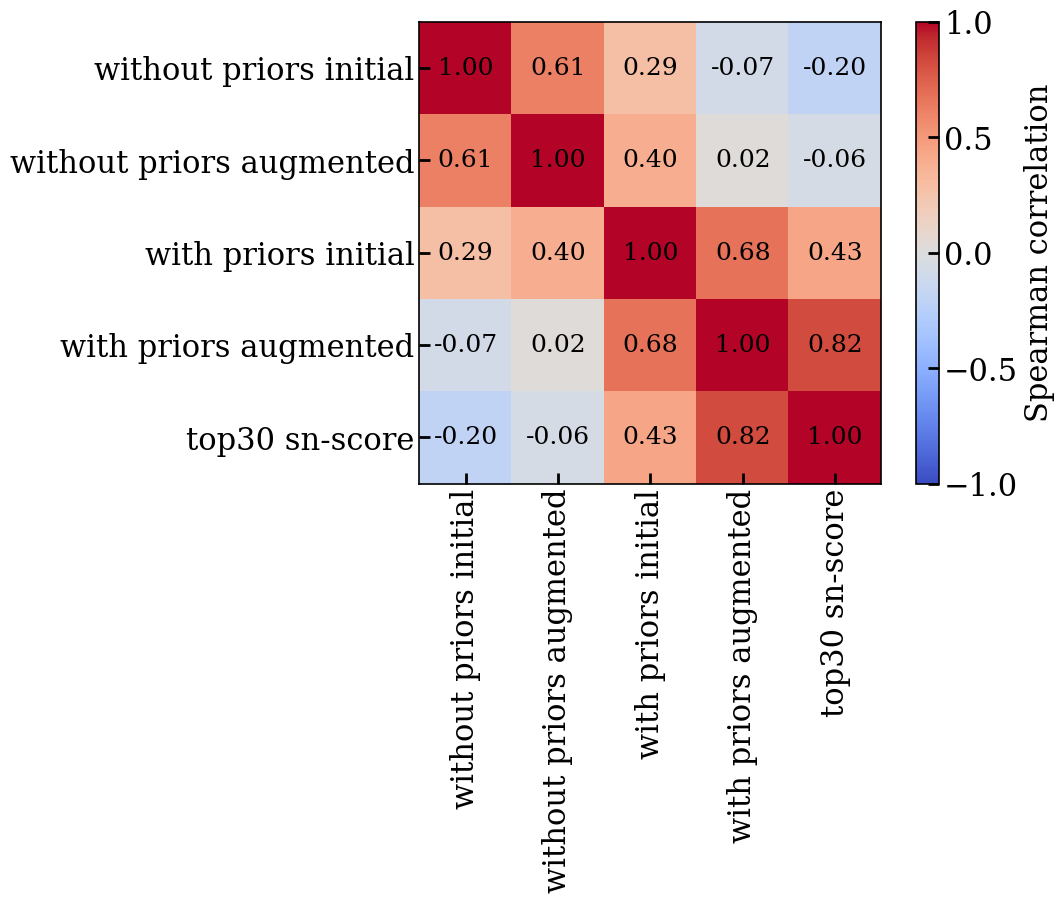

In [22]:
cols = ['without priors initial', 'without priors augmented',
        'with priors initial', 'with priors augmented', 'top30 sn-score']

corr = df[cols].corr(method='spearman')


fig, ax = plt.subplots(figsize=(9, 6))
plt.imshow(corr_spearman, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Spearman correlation')
plt.xticks(range(len(cols)), cols, rotation=90)
plt.yticks(range(len(cols)), cols)
for i in range(len(cols)):
    for j in range(len(cols)):
        value = corr.iloc[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", color="black", fontsize=18)
        
plt.savefig('../figures/correlation.pdf', dpi=400, format='pdf', bbox_inches="tight")